   epoch  train_loss  train_mse  train_rel  train_grad_t  train_grad_x  \
0      1    0.930187   0.826070   1.025882      0.061425      0.014980   
1      2    0.699551   0.611158   0.868214      0.063271      0.015303   
2      3    0.587980   0.509551   0.768655      0.062581      0.015599   
3      4    0.463959   0.395113   0.673278      0.060220      0.015734   
4      5    0.399137   0.334370   0.632651      0.058981      0.016126   

   train_fft  val_loss   val_mse   val_mae   val_rel  val_grad_t  val_grad_x  \
0   0.055288  0.669368  0.568464  0.233864  0.993758    0.061602    0.014803   
1   0.053655  0.525817  0.450701  0.185498  0.736728    0.057675    0.014489   
2   0.051078  0.420277  0.353687  0.165759  0.651478    0.057708    0.014417   
3   0.048137  0.387567  0.321567  0.169170  0.644710    0.060908    0.015507   
4   0.046718  0.346502  0.285536  0.155469  0.594757    0.058961    0.015542   

    val_fft     lr  
0  0.054950  0.001  
1  0.048265  0.001  
2  0.045486

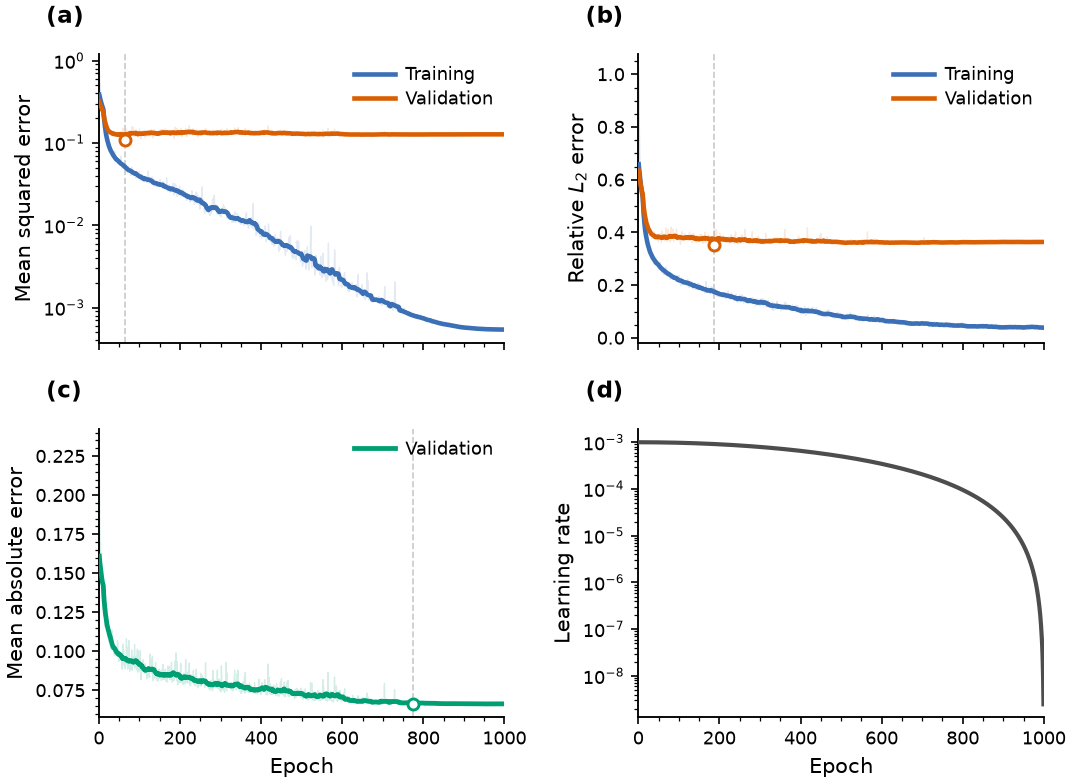

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


# ============================================================
# 1. Load data
# ============================================================
csv_path = "training_log.csv"

df = pd.read_csv(csv_path)

print(df.head())
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. Smooth curves
# ============================================================
smooth_window = 20

metrics = [
    "train_mse",
    "val_mse",
    "train_rel",
    "val_rel",
    "val_mae",
]

for col in metrics:
    df[f"{col}_smooth"] = (
        df[col]
        .rolling(
            window=smooth_window,
            center=True,
            min_periods=1
        )
        .mean()
    )


# ============================================================
# 3. Nature-style color palette
# ============================================================
COLOR_TRAIN = "#3B6FB6"   # muted scientific blue
COLOR_VAL   = "#D95F02"   # orange-red
COLOR_MAE   = "#009E73"   # teal green
COLOR_LR    = "#4D4D4D"   # charcoal gray


# ============================================================
# 4. Global Nature-style settings
# ============================================================
mpl.rcParams.update({

    # Font
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans"
    ],

    "font.size": 9,

    "axes.labelsize": 10,
    "axes.titlesize": 10,

    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,

    "legend.fontsize": 8.5,

    # Axes
    "axes.linewidth": 0.9,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,

    # Output
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
})


# ============================================================
# 5. Find minimum validation values
# ============================================================
best_mse_idx = df["val_mse"].idxmin()
best_rel_idx = df["val_rel"].idxmin()
best_mae_idx = df["val_mae"].idxmin()

best_mse_epoch = int(df.loc[best_mse_idx, "epoch"])
best_rel_epoch = int(df.loc[best_rel_idx, "epoch"])
best_mae_epoch = int(df.loc[best_mae_idx, "epoch"])


print(
    f"Best Val MSE    = "
    f"{df.loc[best_mse_idx, 'val_mse']:.6e} "
    f"at epoch {best_mse_epoch}"
)

print(
    f"Best Val Rel L2 = "
    f"{df.loc[best_rel_idx, 'val_rel']:.6e} "
    f"at epoch {best_rel_epoch}"
)

print(
    f"Best Val MAE    = "
    f"{df.loc[best_mae_idx, 'val_mae']:.6e} "
    f"at epoch {best_mae_epoch}"
)


# ============================================================
# 6. Create 2 x 2 figure
# ============================================================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.2, 5.2)
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]


# ============================================================
# Panel label helper
# ============================================================
def panel_label(ax, label):

    ax.text(
        -0.13,
        1.17,
        label,

        transform=ax.transAxes,

        fontsize=11,
        fontweight="bold",

        va="top",
        ha="left"
    )


# ============================================================
# (a) Mean squared error
# ============================================================

# Raw training
ax1.plot(
    df["epoch"],
    df["train_mse"],

    color=COLOR_TRAIN,

    linewidth=0.65,
    alpha=0.14,

    zorder=1
)

# Raw validation
ax1.plot(
    df["epoch"],
    df["val_mse"],

    color=COLOR_VAL,

    linewidth=0.65,
    alpha=0.14,

    zorder=1
)


# Smoothed training
ax1.plot(
    df["epoch"],
    df["train_mse_smooth"],

    color=COLOR_TRAIN,

    linewidth=2.2,

    label="Training",

    zorder=3
)

# Smoothed validation
ax1.plot(
    df["epoch"],
    df["val_mse_smooth"],

    color=COLOR_VAL,

    linewidth=2.2,

    label="Validation",

    zorder=3
)


# Minimum point
ax1.scatter(
    best_mse_epoch,
    df.loc[best_mse_idx, "val_mse"],

    s=28,

    facecolor="white",
    edgecolor=COLOR_VAL,

    linewidth=1.4,

    zorder=5
)


ax1.set_yscale("log")

ax1.set_ylabel("Mean squared error")

panel_label(ax1, "(a)")

ax1.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15,
    labelspacing=0.35
)


# ============================================================
# (b) Relative L2 error
# ============================================================

# Raw training
ax2.plot(
    df["epoch"],
    df["train_rel"],

    color=COLOR_TRAIN,

    linewidth=0.65,
    alpha=0.14,

    zorder=1
)

# Raw validation
ax2.plot(
    df["epoch"],
    df["val_rel"],

    color=COLOR_VAL,

    linewidth=0.65,
    alpha=0.14,

    zorder=1
)


# Smoothed training
ax2.plot(
    df["epoch"],
    df["train_rel_smooth"],

    color=COLOR_TRAIN,

    linewidth=2.2,

    label="Training",

    zorder=3
)

# Smoothed validation
ax2.plot(
    df["epoch"],
    df["val_rel_smooth"],

    color=COLOR_VAL,

    linewidth=2.2,

    label="Validation",

    zorder=3
)


# Minimum point
ax2.scatter(
    best_rel_epoch,
    df.loc[best_rel_idx, "val_rel"],

    s=28,

    facecolor="white",
    edgecolor=COLOR_VAL,

    linewidth=1.4,

    zorder=5
)


ax2.set_ylabel(r"Relative $L_2$ error")

panel_label(ax2, "(b)")

ax2.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15,
    labelspacing=0.35
)


# ============================================================
# (c) Mean absolute error
# ============================================================

# Raw validation curve
ax3.plot(
    df["epoch"],
    df["val_mae"],

    color=COLOR_MAE,

    linewidth=0.65,
    alpha=0.17,

    zorder=1
)


# Smoothed curve
ax3.plot(
    df["epoch"],
    df["val_mae_smooth"],

    color=COLOR_MAE,

    linewidth=2.3,

    label="Validation",

    zorder=3
)


# Minimum point
ax3.scatter(
    best_mae_epoch,
    df.loc[best_mae_idx, "val_mae"],

    s=28,

    facecolor="white",
    edgecolor=COLOR_MAE,

    linewidth=1.4,

    zorder=5
)


ax3.set_xlabel("Epoch")
ax3.set_ylabel("Mean absolute error")

panel_label(ax3, "(c)")

ax3.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15
)


# ============================================================
# (d) Learning-rate schedule
# ============================================================

# Zero cannot be shown on log scale
lr_plot = df["lr"].replace(0, np.nan)

ax4.plot(
    df["epoch"],
    lr_plot,

    color=COLOR_LR,

    linewidth=2.0,

    zorder=3
)

ax4.set_yscale("log")

ax4.set_xlabel("Epoch")
ax4.set_ylabel("Learning rate")

panel_label(ax4, "(d)")


# ============================================================
# 7. Common formatting
# ============================================================
for ax in axes.flat:

    # Open axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    # Ticks
    ax.tick_params(
        axis="both",
        which="both",

        direction="out",

        top=False,
        right=False,

        pad=3
    )

    ax.minorticks_on()

    # Epoch limits
    ax.set_xlim(
        df["epoch"].min(),
        df["epoch"].max()
    )

    ax.set_xticks([
        0,
        200,
        400,
        600,
        800,
        1000
    ])

    ax.margins(x=0)

    # Cleaner Nature-style appearance
    ax.grid(False)


# Hide x labels in top row
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
# ============================================================
# Find best epoch for each metric separately
# ============================================================

best_mse_idx = df["val_mse"].idxmin()
best_rel_idx = df["val_rel"].idxmin()
best_mae_idx = df["val_mae"].idxmin()

best_mse_epoch = int(df.loc[best_mse_idx, "epoch"])
best_rel_epoch = int(df.loc[best_rel_idx, "epoch"])
best_mae_epoch = int(df.loc[best_mae_idx, "epoch"])

print(
    f"Best Val MSE = {df.loc[best_mse_idx, 'val_mse']:.6f} "
    f"at epoch {best_mse_epoch}"
)

print(
    f"Best Val Rel L2 = {df.loc[best_rel_idx, 'val_rel']:.6f} "
    f"at epoch {best_rel_epoch}"
)

print(
    f"Best Val MAE = {df.loc[best_mae_idx, 'val_mae']:.6f} "
    f"at epoch {best_mae_epoch}"
)

# MSE best epoch
ax1.axvline(
    best_mse_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)

# Relative L2 best epoch
ax2.axvline(
    best_rel_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)

# MAE best epoch
ax3.axvline(
    best_mae_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)


# ============================================================
# 8. Layout
# ============================================================
plt.subplots_adjust(
    left=0.11,
    right=0.985,

    bottom=0.11,
    top=0.96,

    wspace=0.33,
    hspace=0.30
)


# ============================================================
# 9. Save
# ============================================================
output_dir = Path("loss_figures")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


fig.savefig(
    output_dir / "training_loss_model3_nature.pdf"
)

fig.savefig(
    output_dir / "training_loss_model3_nature.svg"
)

fig.savefig(
    output_dir / "training_loss_model3_nature.png",
    dpi=600
)


plt.show()